In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

print("--> Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Set reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("-- Seed set. Using device:", device)

-- Seed set. Using device: cpu


In [ ]:
# Define Transforms

img_size = 224

transform_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("--> Data transforms defined.")


--> Data transforms defined.


In [ ]:
# Load Dataset
data_dir = "D:\\ML-research\\Datasets\\chest_xray_images"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform_train)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("--> Dataset loaded with classes:", class_names)

# Count class samples in train
train_counter = Counter(train_dataset.targets)
val_counter = Counter(val_dataset.targets)

print("\n-- Train Dataset Count --")
for class_idx, class_name in enumerate(class_names):
    print(f"{class_name}: {train_counter[class_idx]}")

print("\n-- Validation Dataset Count --")
for class_idx, class_name in enumerate(class_names):
    print(f"{class_name}: {val_counter[class_idx]}")


--> Dataset loaded with classes: ['bacterial', 'normal', 'viral']

-- Train Dataset Count --
bacterial: 2100
normal: 2289
viral: 1159

-- Validation Dataset Count --
bacterial: 450
normal: 490
viral: 248


In [ ]:
# Define ResFormer Model
class ResFormer(nn.Module):
    def __init__(self, num_classes):
        super(ResFormer, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity()  # remove fc
        self.embedding_dim = 2048
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=self.embedding_dim, nhead=8, dim_feedforward=512),
            num_layers=1
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(self.embedding_dim, num_classes)

    def forward(self, x):
        x = self.resnet(x)  # [B, 2048]
        x = x.unsqueeze(1)  # [B, 1, 2048]
        x = self.transformer(x)  # [B, 1, 2048]
        x = x.squeeze(1)  # [B, 2048]
        x = self.classifier(x)  # [B, num_classes]
        return x

model = ResFormer(num_classes=len(class_names)).to(device)
print("--> ResFormer model defined.")


d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--> ResFormer model defined.


d:\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
# Initialize Loss Function, Optimizer, and Scheduler

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print("--> Loss function, optimizer, and scheduler initialized.")


--> Loss function, optimizer, and scheduler initialized.


In [7]:
# raining Loop with Validation, Confusion Matrix, and Best Model Saving

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):
    best_acc = 0
    print("-> Training started...")
    
    for epoch in range(num_epochs):
        print(f"\n Epoch {epoch+1}/{num_epochs}")
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        correct_val = 0
        total_val = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = outputs.max(1)
                correct_val += preds.eq(labels).sum().item()
                total_val += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = 100. * correct_val / total_val
        scheduler.step(val_acc)

        print(f"--> Epoch {epoch+1} Result → Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Loss: {train_loss/len(train_loader):.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  <--> New best model saved at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")

        # Show detailed classification metrics
        print("-- Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))
        print("-- Confusion Matrix:")
        print(confusion_matrix(all_labels, all_preds))

    print(f"\n #--# Training completed. Best Validation Accuracy: {best_acc:.2f}%")

# Call the function
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler)


-> Training started...

 Epoch 1/20


Epoch 1: 100%|██████████| 174/174 [27:40<00:00,  9.55s/it] 


--> Epoch 1 Result → Train Acc: 75.38% | Val Acc: 76.94% | Loss: 0.5737
  <--> New best model saved at epoch 1 with Val Acc: 76.94%
-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.65      0.95      0.77       450
      normal       0.93      0.97      0.95       490
       viral       0.79      0.04      0.08       248

    accuracy                           0.77      1188
   macro avg       0.79      0.66      0.60      1188
weighted avg       0.79      0.77      0.70      1188

-- Confusion Matrix:
[[429  18   3]
 [ 16 474   0]
 [219  18  11]]

 Epoch 2/20


Epoch 2: 100%|██████████| 174/174 [28:19<00:00,  9.77s/it] 


--> Epoch 2 Result → Train Acc: 81.67% | Val Acc: 84.09% | Loss: 0.4270
  <--> New best model saved at epoch 2 with Val Acc: 84.09%
-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.78      0.88      0.83       450
      normal       0.95      0.99      0.97       490
       viral       0.69      0.48      0.56       248

    accuracy                           0.84      1188
   macro avg       0.81      0.78      0.79      1188
weighted avg       0.83      0.84      0.83      1188

-- Confusion Matrix:
[[397   4  49]
 [  2 484   4]
 [110  20 118]]

 Epoch 3/20


...

--> Epoch 18 Result → Train Acc: 94.63% | Val Acc: 87.04% | Loss: 0.1468
-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.84      0.87      0.85       450
      normal       0.95      1.00      0.97       490
       viral       0.74      0.62      0.68       248

    accuracy                           0.87      1188
   macro avg       0.84      0.83      0.83      1188
weighted avg       0.86      0.87      0.87      1188

-- Confusion Matrix:
[[390   6  54]
 [  0 489   1]
 [ 74  19 155]]

 Epoch 19/20


Epoch 19: 100%|██████████| 174/174 [24:57<00:00,  8.60s/it]


--> Epoch 19 Result → Train Acc: 94.66% | Val Acc: 87.79% | Loss: 0.1486
-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.87      0.83      0.85       450
      normal       0.98      0.99      0.98       490
       viral       0.71      0.73      0.72       248

    accuracy                           0.88      1188
   macro avg       0.85      0.85      0.85      1188
weighted avg       0.88      0.88      0.88      1188

-- Confusion Matrix:
[[374   4  72]
 [  0 487   3]
 [ 58   8 182]]

 Epoch 20/20


Epoch 20: 100%|██████████| 174/174 [24:42<00:00,  8.52s/it]


--> Epoch 20 Result → Train Acc: 96.11% | Val Acc: 87.79% | Loss: 0.1091
-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.85      0.86      0.86       450
      normal       0.96      1.00      0.98       490
       viral       0.74      0.68      0.71       248

    accuracy                           0.88      1188
   macro avg       0.85      0.84      0.85      1188
weighted avg       0.87      0.88      0.88      1188

-- Confusion Matrix:
[[386   5  59]
 [  0 489   1]
 [ 66  14 168]]

 #--# Training completed. Best Validation Accuracy: 88.22%


In [8]:
# Install torchcam for visualization
%pip install torchcam

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: torchcam in d:\anaconda3\lib\site-packages (0.4.0)



In [9]:
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import GradCAMpp
from torchcam.utils import overlay_mask
print("-->  Grad-CAM++ library loaded.")

-->  Grad-CAM++ library loaded.


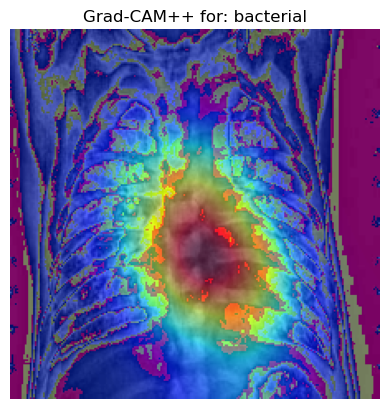

--> Grad-CAM++ visualization displayed successfully.


In [10]:
# Grad-CAM++ visualization 

from torchcam.methods import GradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

def show_gradcam_fixed(model, image_tensor, class_idx=None):
    model.eval()
    
    # --> Correct target layer name
    cam_extractor = GradCAMpp(model.resnet, target_layer='layer4')
    
    image_tensor = image_tensor.unsqueeze(0).to(device)
    out = model(image_tensor)
    pred_class = out.argmax(dim=1).item() if class_idx is None else class_idx

    # Forward pass needed for activation extraction
    _ = model.resnet(image_tensor)

    # Get CAM
    activation_map = cam_extractor(pred_class, out)

    # Convert to image
    img_pil = to_pil_image(image_tensor.squeeze(0).cpu())
    mask_pil = to_pil_image(activation_map[0].cpu(), mode='F')
    result = overlay_mask(img_pil, mask_pil, alpha=0.5)

    plt.imshow(result)
    plt.title(f"Grad-CAM++ for: {class_names[pred_class]}")
    plt.axis('off')
    plt.show()

    print("--> Grad-CAM++ visualization displayed successfully.")

# Example usage
sample_img, _ = val_dataset[0]
show_gradcam_fixed(model, sample_img)


In [11]:

# Load best model before evaluation
model_clean = ResFormer(num_classes=len(class_names)).to(device)
model_clean.load_state_dict(torch.load("best_model.pth", map_location=device))
model_clean.eval()
print("--> Fresh model loaded for evaluation (no Grad-CAM hooks).")



d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
d:\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


--> Fresh model loaded for evaluation (no Grad-CAM hooks).


In [ ]:

# Step 13: Load best model and evaluate
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="🔍 Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    print(f"--> Final Accuracy: {accuracy:.2f}% on {total} samples")
    print("\n-- Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("-- Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

# Reload best weights before evaluating
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
print("--> Best model loaded for evaluation.")

# Call evaluation
evaluate_model(model_clean, val_loader)



--> Best model loaded for evaluation.


🔍 Evaluating: 100%|██████████| 38/38 [01:50<00:00,  2.91s/it]

--> Final Accuracy: 88.22% on 1188 samples

-- Classification Report:
              precision    recall  f1-score   support

   bacterial       0.82      0.91      0.86       450
      normal       0.98      1.00      0.99       490
       viral       0.79      0.60      0.69       248

    accuracy                           0.88      1188
   macro avg       0.86      0.84      0.85      1188
weighted avg       0.88      0.88      0.88      1188

-- Confusion Matrix:
[[410   2  38]
 [  1 488   1]
 [ 91   7 150]]


In [13]:
# Modify Train Function to Return History
def train_model_with_history(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):
    best_acc = 0
    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": []
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = outputs.max(1)
                correct_val += preds.eq(labels).sum().item()
                total_val += labels.size(0)

        val_acc = 100. * correct_val / total_val
        scheduler.step(val_acc)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss / len(train_loader))

        print(f"--> Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Loss: {train_loss/len(train_loader):.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  --> New best model saved at epoch {epoch+1}")

    print(f"\n #--# Training finished. Best Val Acc: {best_acc:.2f}%")
    return history


In [14]:
# Plot Graphs

def plot_training_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], label='Train Accuracy')
    plt.plot(epochs, history["val_acc"], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], label='Train Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
    print("--> Training graphs plotted.")




-- Grad-CAM++ module imported and ready.
--> Best model loaded for Grad-CAM++ visualization.
--> Identifying 5 misclassified images...
--> Now displaying Grad-CAM++ for 5 misclassified validation images:


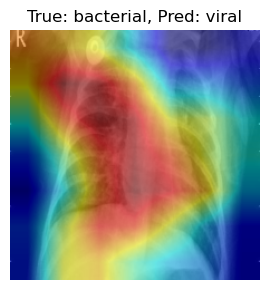

--> Misclassified Image 1 saved at: gradcam_misclassified\misclassified_1_true_bacterial_pred_viral.jpg


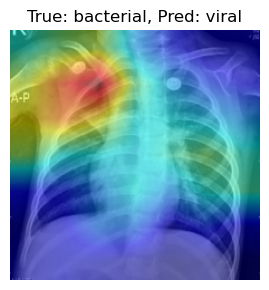

--> Misclassified Image 2 saved at: gradcam_misclassified\misclassified_2_true_bacterial_pred_viral.jpg


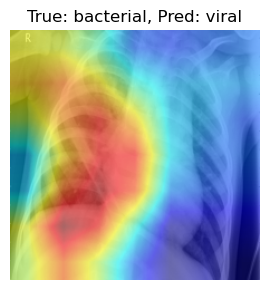

--> Misclassified Image 3 saved at: gradcam_misclassified\misclassified_3_true_bacterial_pred_viral.jpg


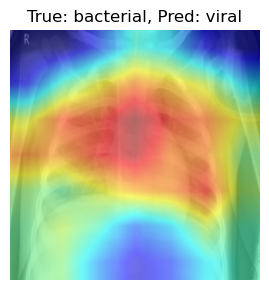

--> Misclassified Image 4 saved at: gradcam_misclassified\misclassified_4_true_bacterial_pred_viral.jpg


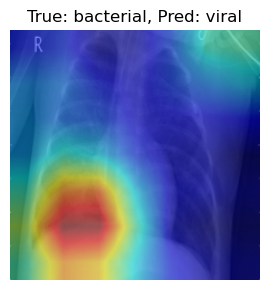

--> Misclassified Image 5 saved at: gradcam_misclassified\misclassified_5_true_bacterial_pred_viral.jpg
--> Grad-CAM++ visualizations completed and hooks cleared.


In [15]:
# Step 10: Grad-CAM++ for Misclassified Images
from torchvision.utils import make_grid
import cv2
from PIL import Image
import torchvision.transforms.functional as F
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("-- Grad-CAM++ module imported and ready.")

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
for param in model.parameters():
    param.requires_grad = True
model.to(device)
print("--> Best model loaded for Grad-CAM++ visualization.")

# Grad-CAM++ setup
target_layer = model.resnet.layer4[-1]
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])

# Denormalization function
def denormalize(tensor):
    tensor = tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    tensor = std * tensor + mean
    tensor = np.clip(tensor, 0, 1)
    return tensor

# Identify 5 misclassified images
misclassified = []
print("--> Identifying 5 misclassified images...")

for images, labels in val_loader:
    images = images.to(device).requires_grad_(True)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(images.size(0)):
        if preds[i] != labels[i]:
            misclassified.append((images[i].detach().cpu(), labels[i].cpu().item(), preds[i].cpu().item()))
        if len(misclassified) >= 5:
            break
    if len(misclassified) >= 5:
        break


# Now apply Grad-CAM++ (requires gradients!)
print("--> Now displaying Grad-CAM++ for 5 misclassified validation images:")


# Folder to save Grad-CAM++ results
save_dir = "gradcam_misclassified"
os.makedirs(save_dir, exist_ok=True)

# Show and save Grad-CAM++ for 5 misclassified images
with GradCAMPlusPlus(model=model, target_layers=[target_layer]) as cam:
    for idx, (img_tensor, label, pred) in enumerate(misclassified):
        input_tensor = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
        rgb_img = denormalize(img_tensor)
        targets = [ClassifierOutputTarget(pred)]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        save_path = os.path.join(save_dir, f"misclassified_{idx+1}_true_{class_names[label]}_pred_{class_names[pred]}.jpg")
        Image.fromarray(cam_image).save(save_path)

        plt.figure(figsize=(6, 3))
        plt.imshow(cam_image)
        plt.title(f"True: {class_names[label]}, Pred: {class_names[pred]}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        print(f"--> Misclassified Image {idx+1} saved at: {save_path}")

# Clear Grad-CAM hooks
del cam
print("--> Grad-CAM++ visualizations completed and hooks cleared.")


In [16]:
# Step 11: Final Test Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Define test transform
transform_test = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load test dataset
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("--> Test set loaded. Number of images:", len(test_dataset))

# Re-initialize and load the best model (clean state without any Grad-CAM hooks)
model = ResFormer(num_classes=3)  # Replace with your model class if different
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()
print("--> Best model reloaded cleanly for test evaluation.")

# Run evaluation
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute and print results
accuracy = accuracy_score(all_labels, all_preds) * 100
report = classification_report(all_labels, all_preds, target_names=class_names)
conf_matrix = confusion_matrix(all_labels, all_preds)

print(f"---> Final Test Accuracy: {accuracy:.2f}%")
print("\n--> Classification Report:\n", report)
print("\n--> Confusion Matrix:\n", conf_matrix)

# Save results
pd.DataFrame(conf_matrix, index=class_names, columns=class_names).to_csv("confusion_matrix.csv")
with open("classification_report.txt", "w") as f:
    f.write(report)

print("\n--> Final results saved: 'confusion_matrix.csv' and 'classification_report.txt'")


--> Test set loaded. Number of images: 1191


d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
d:\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


--> Best model reloaded cleanly for test evaluation.
---> Final Test Accuracy: 88.25%

--> Classification Report:
               precision    recall  f1-score   support

   bacterial       0.82      0.89      0.86       451
      normal       0.98      0.99      0.99       491
       viral       0.78      0.65      0.71       249

    accuracy                           0.88      1191
   macro avg       0.86      0.84      0.85      1191
weighted avg       0.88      0.88      0.88      1191


--> Confusion Matrix:
 [[403   5  43]
 [  2 487   2]
 [ 84   4 161]]

--> Final results saved: 'confusion_matrix.csv' and 'classification_report.txt'
